#### Modules

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

#### Creat two dataframes to store labels and image data  (df_walls & df_decks)

In [ ]:
# File path to wall and deck images
data_dirs = {"Walls": "Training_Pool_A_Walls",
             "Decks": "Training_Pool_B_Decks"}

# Labels imposed on each image based on dataset
categories = ["Cracked", "Non-Cracked"]

# Temporary lists to hold our data before creating DataFrames
walls_data = []
decks_data = []

# Read the cracked walls, uncracked walls, cracked decks, and uncracked decks
for domain, root_dir in data_dirs.items():
    for cat in categories:
        path = os.path.join(root_dir, cat)
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for f in files:
                img_path = os.path.join(path, f)
                try:
                    with Image.open(img_path) as img:
                        # Store file name, label and image array in Grey format (1x256x256)
                        img_array = np.array(img.convert('L'))
                        entry = {"FileName": f, 
                                 "Label": cat,
                                 "ImageData": img_array}
                        # If the domain is Walls, append to walls_data, else append to decks_data
                        if domain == "Walls":
                            walls_data.append(entry)
                        else:
                            decks_data.append(entry)
                except Exception as e:
                    print(f"Error loading {f}: {e}")

# Create the Three DataFrames
df_walls = pd.DataFrame(walls_data)
df_decks = pd.DataFrame(decks_data)
df_combined = pd.concat([df_walls, df_decks], ignore_index=True)

#### What the dataframe looks like

In [5]:
print(df_walls.head())
print(f'\nOverall shape of the dataframe: {df_walls.shape} \n')
print(f'Shape of the image data: {df_walls.iloc[0]["ImageData"].shape}')

       FileName    Label                                          ImageData
0  7069-101.jpg  Cracked  [[156, 155, 154, 155, 157, 159, 159, 159, 147,...
1  7069-104.jpg  Cracked  [[168, 166, 166, 168, 166, 164, 166, 171, 171,...
2  7069-105.jpg  Cracked  [[169, 169, 168, 166, 165, 164, 164, 163, 165,...
3  7069-108.jpg  Cracked  [[169, 169, 169, 170, 170, 168, 163, 159, 157,...
4  7069-118.jpg  Cracked  [[178, 183, 184, 182, 182, 186, 186, 183, 181,...

Overall shape of the dataframe: (17939, 3) 

Shape of the image data: (256, 256)


#### Example for How to retrieve data 

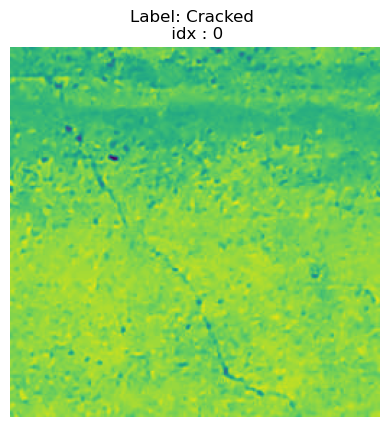

In [6]:
# Show the first image in the Walls set
file_number = 0
plt.imshow(df_walls[df_walls['Label'] == 'Cracked'].iloc[file_number]['ImageData'])
plt.title(f"Label: {df_walls[df_walls['Label'] == 'Cracked'].iloc[file_number]['Label']} \n idx : {file_number}")
plt.axis('off')
plt.show()

#### Export dataframes

Use pickle format because it is able to store the 3D image data arrays

In [13]:
df_walls.to_pickle('wall_data.pkl')
df_decks.to_pickle('deck_data.pkl')